In [8]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from faker import Faker
import random

Create a dataset representing daily stock prices for at least 250 trading days with:


date, open_price, close_price, volume


In [9]:
data=[]
faker=Faker()
for i in  range(250):
    data.append({
        "Date":faker.date(),
        "open_price":faker.random_int(100,10000),
        "close_price":faker.random_int(100,10000),
        "volume":faker.random_int(10,1000)
    })
df=pd.DataFrame(data)
df.to_csv("Stock_Market.csv",index=False)
print(df.head(10))

         Date  open_price  close_price  volume
0  2004-02-24        2001          586     129
1  1998-12-17        7938         9302     534
2  1982-12-14        7812          454     373
3  1999-09-28         995         7167     431
4  1973-01-21        8065         2166     634
5  1996-02-10        9050         8324     466
6  1971-08-19        9934         9796     370
7  2006-02-06        5338         9865     718
8  1972-02-13        9129         2507     382
9  2010-04-10        9576         9382     824


Using Pandas:
Calculate daily returns and rolling volatility.

In [10]:
df["daily_return"]=df["close_price"].pct_change()
df.head(10)

,Date,open_price,close_price,volume,daily_return
0,2004-02-24,2001,586,129,NaN
1,1998-12-17,7938,9302,534,14.873720
2,1982-12-14,7812,454,373,-0.951193
3,1999-09-28,995,7167,431,14.786344
4,1973-01-21,8065,2166,634,-0.697781
5,1996-02-10,9050,8324,466,2.843029
6,1971-08-19,9934,9796,370,0.176838
7,2006-02-06,5338,9865,718,0.007044
8,1972-02-13,9129,2507,382,-0.745869
9,2010-04-10,9576,9382,824,2.742321


In [14]:
df["rolling_volatility"]=df["daily_return"].rolling(window=3).std()
df.head(10)

,Date,open_price,close_price,volume,daily_return,rolling_volatility
0,2004-02-24,2001,586,129,NaN,NaN
1,1998-12-17,7938,9302,534,14.873720,NaN
2,1982-12-14,7812,454,373,-0.951193,NaN
3,1999-09-28,995,7167,431,14.786344,9.111399
4,1973-01-21,8065,2166,634,-0.697781,9.013808
5,1996-02-10,9050,8324,466,2.843029,8.113140
6,1971-08-19,9934,9796,370,0.176838,1.844400
7,2006-02-06,5338,9865,718,0.007044,1.590609
8,1972-02-13,9129,2507,382,-0.745869,0.491104
9,2010-04-10,9576,9382,824,2.742321,1.835579


Using NumPy:
Simulate future stock prices.

In [16]:

last_price = df['close_price'].iloc[-1]
simulated_prices = []
price = last_price
for i in range(30):
    simulated_return = np.random.normal(df['daily_return'].mean(),                          df['daily_return'].std())
    price = price * (1 + simulated_return)
    simulated_prices.append(price)
simulated_prices

[np.float64(71488.5912811786),
 np.float64(169559.19102189504),
 np.float64(428382.49928680586),
 np.float64(3791311.8703182074),
 np.float64(-2092845.3623052032),
 np.float64(-13648285.985495882),
 np.float64(-85637530.74653466),
 np.float64(187252115.7281855),
 np.float64(955982176.6674021),
 np.float64(4037528345.311727),
 np.float64(-8094238086.420067),
 np.float64(-26102649823.249626),
 np.float64(-88133892846.29466),
 np.float64(-130168473076.74585),
 np.float64(-560374149532.8564),
 np.float64(2652853044532.9707),
 np.float64(-569450929567.7933),
 np.float64(-2531321039626.9727),
 np.float64(-10957827800813.45),
 np.float64(44672840606948.63),
 np.float64(54750685768409.39),
 np.float64(108950120430804.12),
 np.float64(432667985513707.75),
 np.float64(-26064264304138.438),
 np.float64(-45346004748500.08),
 np.float64(-120570889438529.4),
 np.float64(-785586079449622.6),
 np.float64(4010926322021965.0),
 np.float64(750689737802523.4),
 np.float64(-23237878725789.67)]

Using NumPy:
Quantify risk using statistical measures.


In [18]:
volatility=np.std(df["daily_return"])
print(volatility)

4.703258196075543


In [20]:
mean_return=np.mean(df["daily_return"])
print(mean_return)

1.163053337971068


In [23]:
# value at risk at 10 %label

Var_10=np.percentile(df["daily_return"],5)
Var_10

np.float64(nan)

In [24]:
sharp_ratio = df['daily_return'].mean() / df['daily_return'].std()
sharp_ratio

np.float64(0.24678967038672037)

Using a visualization library:
Plot price trends over time.

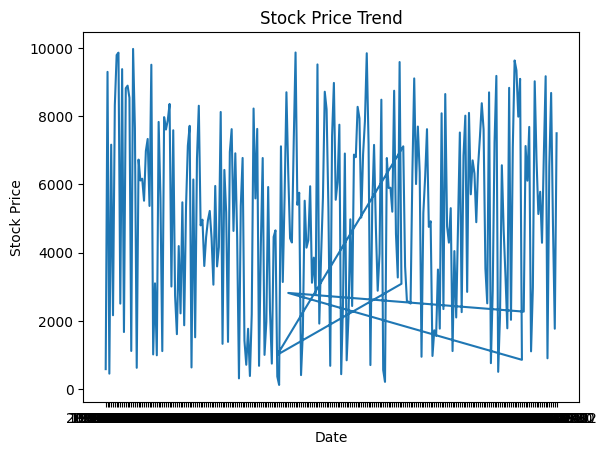

In [31]:
plt.plot(df["Date"],df["close_price"])
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.title("Stock Price Trend")
plt.show()

Visualize return distributions.

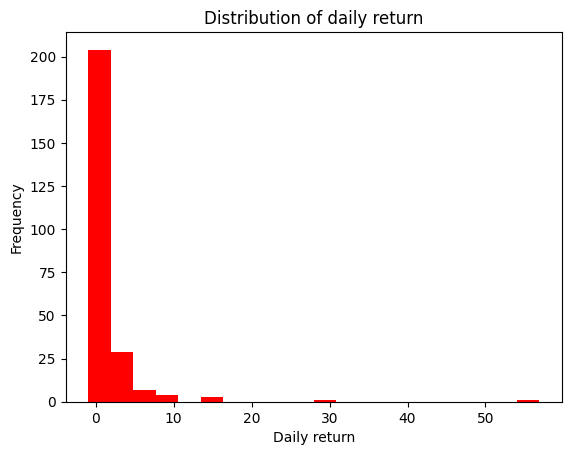

In [37]:
plt.hist(df["daily_return"].dropna(),bins=20,color="red")
plt.title("Distribution of daily return")
plt.xlabel("Daily return")
plt.ylabel("Frequency")
plt.show()